
# HW3
## Mahan Fallahpour
## 810802083


<hr style="border: 2px solid black;">

# Q1:

Number of boundary components: 3


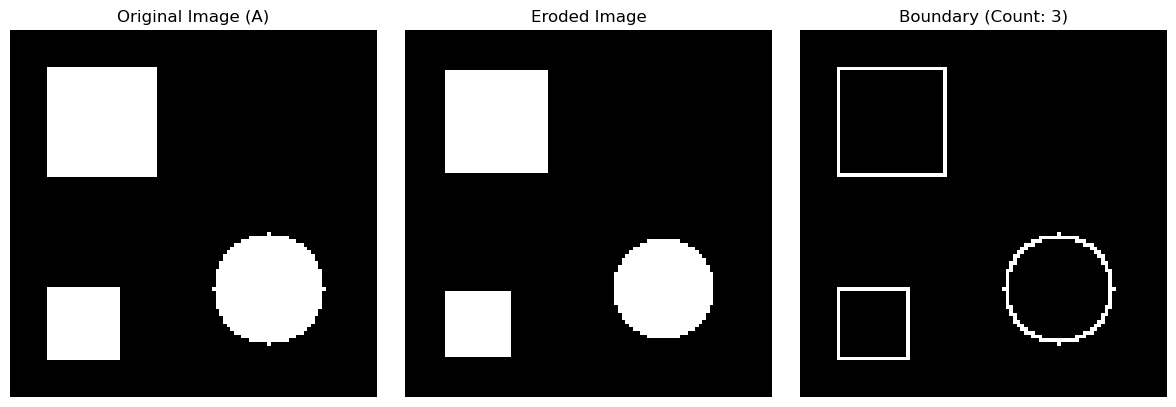

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def create_synthetic_image():
    img = np.zeros((100, 100), dtype=np.uint8)
    img[10:40, 10:40] = 1
    
    for i in range(50, 90):
        for j in range(50, 90):
            if (i - 70)**2 + (j - 70)**2 <= 15**2:
                img[i, j] = 1
                
    img[70:90, 10:30] = 1
    return img

def manual_erosion(image, kernel):
    k_h, k_w = kernel.shape
    pad_h, pad_w = k_h // 2, k_w // 2
    
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    eroded = np.zeros_like(image)
    
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+k_h, j:j+k_w]
            if np.array_equal(region & kernel, kernel):
                eroded[i, j] = 1
                
    return eroded

def count_components(image):
    visited = np.zeros_like(image, dtype=bool)
    count = 0
    h, w = image.shape
    
    def dfs(r, c):
        stack = [(r, c)]
        while stack:
            curr_r, curr_c = stack.pop()
            if curr_r < 0 or curr_r >= h or curr_c < 0 or curr_c >= w:
                continue
            if visited[curr_r, curr_c] or image[curr_r, curr_c] == 0:
                continue
                
            visited[curr_r, curr_c] = True
            
            stack.extend([
                (curr_r+1, curr_c), (curr_r-1, curr_c), 
                (curr_r, curr_c+1), (curr_r, curr_c-1),
                (curr_r+1, curr_c+1), (curr_r-1, curr_c-1), 
                (curr_r+1, curr_c-1), (curr_r-1, curr_c+1)
            ])

    for i in range(h):
        for j in range(w):
            if image[i, j] == 1 and not visited[i, j]:
                count += 1
                dfs(i, j)
                
    return count

if __name__ == '__main__':
    A = create_synthetic_image()
    B = np.ones((3, 3), dtype=np.uint8)
    
    eroded_A = manual_erosion(A, B)
    boundary = A - eroded_A
    
    num_components = count_components(boundary)
    print(f"Number of boundary components: {num_components}")
    
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    axes[0].imshow(A, cmap='gray')
    axes[0].set_title('Original Image (A)')
    axes[0].axis('off')
    
    axes[1].imshow(eroded_A, cmap='gray')
    axes[1].set_title('Eroded Image')
    axes[1].axis('off')
    
    axes[2].imshow(boundary, cmap='gray')
    axes[2].set_title(f'Boundary (Count: {num_components})')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

<hr style="border: 2px solid black;">

# Q2:

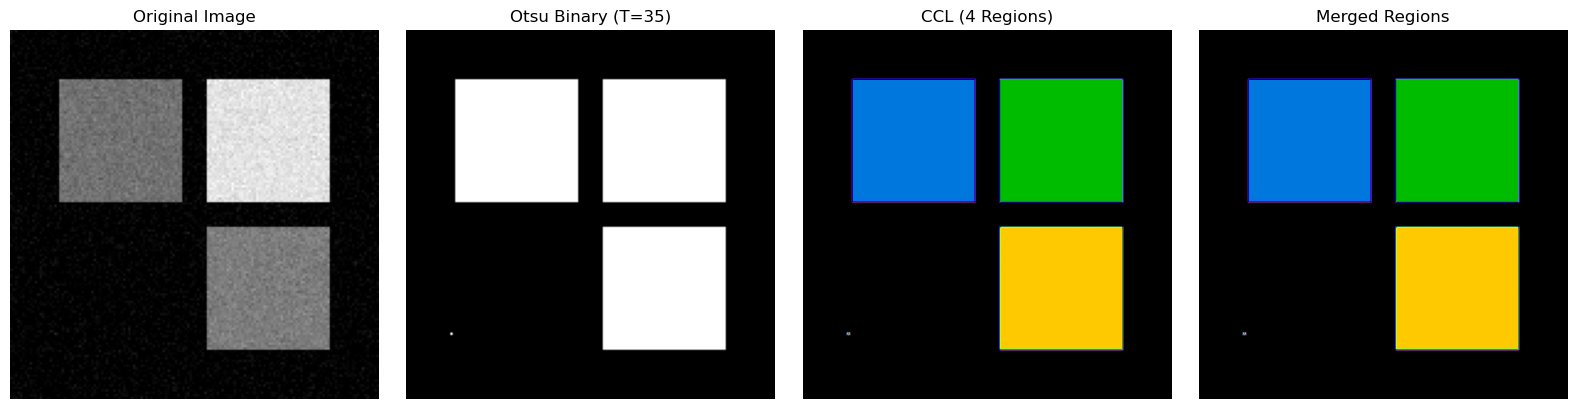

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def create_test_image():
    img = np.zeros((150, 150), dtype=np.uint8)
    img[20:70, 20:70] = 100
    img[80:130, 80:130] = 110
    img[20:70, 80:130] = 200
    
    noise = np.random.normal(0, 8, img.shape)
    noisy_img = np.clip(img + noise, 0, 255).astype(np.uint8)
    return noisy_img

def get_otsu_threshold(img):
    hist = np.bincount(img.flatten(), minlength=256)
    total = img.size
    
    current_max = 0
    threshold = 0
    sum_total = np.sum(np.arange(256) * hist)
    
    weight_bg = 0
    sum_bg = 0
    
    for t in range(256):
        weight_bg += hist[t]
        if weight_bg == 0:
            continue
            
        weight_fg = total - weight_bg
        if weight_fg == 0:
            break
            
        sum_bg += t * hist[t]
        
        mean_bg = sum_bg / weight_bg
        mean_fg = (sum_total - sum_bg) / weight_fg
        
        var_between = weight_bg * weight_fg * (mean_bg - mean_fg) ** 2
        
        if var_between > current_max:
            current_max = var_between
            threshold = t
            
    return threshold

def connected_components(binary_img):
    labeled = np.zeros_like(binary_img, dtype=int)
    label = 1
    h, w = binary_img.shape
    
    for i in range(h):
        for j in range(w):
            if binary_img[i, j] > 0 and labeled[i, j] == 0:
                stack = [(i, j)]
                while stack:
                    r, c = stack.pop()
                    if r < 0 or r >= h or c < 0 or c >= w:
                        continue
                    if binary_img[r, c] == 0 or labeled[r, c] > 0:
                        continue
                        
                    labeled[r, c] = label
                    
                    stack.extend([(r-1, c), (r+1, c), (r, c-1), (r, c+1)])
                label += 1
                
    return labeled, label - 1

def merge_regions(labeled, original, diff_thresh):
    num_labels = np.max(labeled)
    adj = np.zeros((num_labels + 1, num_labels + 1), dtype=bool)
    h, w = labeled.shape
    
    for i in range(h):
        for j in range(w):
            curr = labeled[i, j]
            if curr == 0:
                continue
                
            if i < h - 1:
                bottom = labeled[i + 1, j]
                if bottom > 0 and curr != bottom:
                    adj[curr, bottom] = adj[bottom, curr] = True
            if j < w - 1:
                right = labeled[i, j + 1]
                if right > 0 and curr != right:
                    adj[curr, right] = adj[right, curr] = True
                    
    means = np.zeros(num_labels + 1)
    for lbl in range(1, num_labels + 1):
        mask = (labeled == lbl)
        if np.any(mask):
            means[lbl] = np.mean(original[mask])
            
    merged = labeled.copy()
    
    for i in range(1, num_labels + 1):
        for j in range(i + 1, num_labels + 1):
            if adj[i, j]:
                if abs(means[i] - means[j]) < diff_thresh:
                    merged[merged == j] = i
                    for k in range(1, num_labels + 1):
                        if adj[j, k]:
                            adj[i, k] = adj[k, i] = True
                            
    return merged

if __name__ == '__main__':
    original = create_test_image()
    
    t = get_otsu_threshold(original)
    binary = (original >= t).astype(np.uint8) * 255
    
    labeled_img, num_labels = connected_components(binary)
    
    merged_img = merge_regions(labeled_img, original, diff_thresh=20)
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    axes[0].imshow(original, cmap='gray')
    axes[0].set_title('Original Image')
    
    axes[1].imshow(binary, cmap='gray')
    axes[1].set_title(f'Otsu Binary (T={t})')
    
    axes[2].imshow(labeled_img, cmap='nipy_spectral')
    axes[2].set_title(f'CCL ({num_labels} Regions)')
    
    axes[3].imshow(merged_img, cmap='nipy_spectral')
    axes[3].set_title('Merged Regions')
    
    for ax in axes:
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

<hr style="border: 2px solid black;">

# Q3:

Total cells detected: 149
Data saved to: cells_data.csv


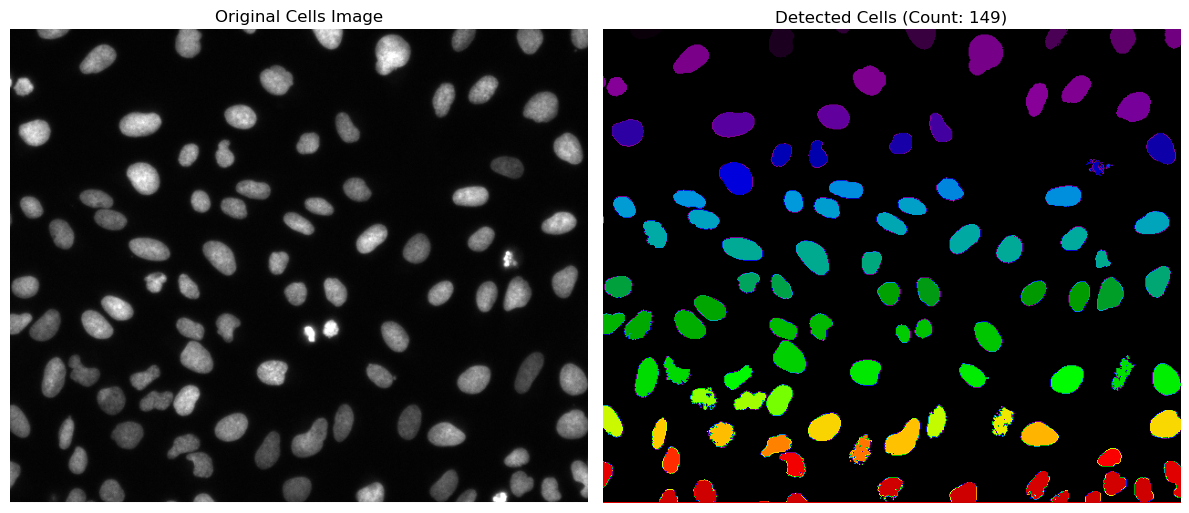

In [7]:
import numpy as np
import cv2
import csv
import matplotlib.pyplot as plt

def get_otsu_threshold(img):
    hist = np.bincount(img.flatten(), minlength=256)
    total = img.size
    current_max = 0
    threshold = 0
    sum_total = np.sum(np.arange(256) * hist)
    weight_bg = 0
    sum_bg = 0
    
    for t in range(256):
        weight_bg += hist[t]
        if weight_bg == 0:
            continue
        weight_fg = total - weight_bg
        if weight_fg == 0:
            break
        sum_bg += t * hist[t]
        mean_bg = sum_bg / weight_bg
        mean_fg = (sum_total - sum_bg) / weight_fg
        var_between = weight_bg * weight_fg * (mean_bg - mean_fg) ** 2
        
        if var_between > current_max:
            current_max = var_between
            threshold = t
            
    return threshold

def connected_components(binary_img):
    labeled = np.zeros_like(binary_img, dtype=int)
    label = 1
    h, w = binary_img.shape
    
    for i in range(h):
        for j in range(w):
            if binary_img[i, j] > 0 and labeled[i, j] == 0:
                stack = [(i, j)]
                while stack:
                    r, c = stack.pop()
                    if r < 0 or r >= h or c < 0 or c >= w:
                        continue
                    if binary_img[r, c] == 0 or labeled[r, c] > 0:
                        continue
                    labeled[r, c] = label
                    stack.extend([(r-1, c), (r+1, c), (r, c-1), (r, c+1)])
                label += 1
                
    return labeled, label - 1

def process_and_extract_features(image_path, excel_output_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    t = get_otsu_threshold(img)
    binary = (img > t).astype(np.uint8) * 255
    
    labeled_img, num_cells = connected_components(binary)
    
    results = []
    for cell_id in range(1, num_cells + 1):
        mask = (labeled_img == cell_id)
        area = np.sum(mask)
        mean_intensity = np.mean(img[mask])
        results.append([cell_id, area, round(mean_intensity, 2)])
        
    with open(excel_output_path, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['Cell ID', 'Area', 'Mean Intensity'])
        writer.writerows(results)
        
    return img, labeled_img, num_cells

if __name__ == '__main__':
    img_path = 'Cells.png'
    out_path = 'cells_data.csv'
    
    original, labeled, count = process_and_extract_features(img_path, out_path)
    
    print(f"Total cells detected: {count}")
    print(f"Data saved to: {out_path}")
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(original, cmap='gray')
    axes[0].set_title('Original Cells Image')
    axes[0].axis('off')
    
    axes[1].imshow(labeled, cmap='nipy_spectral')
    axes[1].set_title(f'Detected Cells (Count: {count})')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()